<a href="https://colab.research.google.com/github/padhab34-bit/IML/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import requests

# URL for the Pima Indians Diabetes Dataset from UCI Machine Learning Repository
dataset_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"

# Define column names based on the description from the provided URL
column_names = [
    'pregnancies',
    'glucose',
    'blood_pressure',
    'skin_thickness',
    'insulin',
    'bmi',
    'diabetes_pedigree_function',
    'age',
    'outcome'
]

try:
    # Read the data directly into a pandas DataFrame
    df = pd.read_csv(dataset_url, names=column_names, sep=',')

    print("Dataset loaded successfully!")
    display(df.head())

except requests.exceptions.RequestException as e:
    print(f"Error downloading the dataset: {e}")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset loaded successfully!


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [23]:
# Define features (X) and target (y) for consistency with the case study structure
pima_data = df.drop('outcome', axis=1).values
pima_target = df['outcome'].values
pima_feature_names = list(df.drop('outcome', axis=1).columns)

# Displaying the shapes and feature names as in the original case study
print(f"Shape of pima_data: {pima_data.shape}")
print(f"Shape of pima_target: {pima_target.shape}")
print(f"Feature Names: {pima_feature_names}")

Shape of pima_data: (768, 8)
Shape of pima_target: (768,)
Feature Names: ['pregnancies', 'glucose', 'blood_pressure', 'skin_thickness', 'insulin', 'bmi', 'diabetes_pedigree_function', 'age']


In [25]:
import pandas as pd

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 9)
pd.set_option('display.width', None)

# Create a DataFrame from the Pima data and add the 'outcome' target
pima_df = pd.DataFrame(pima_data, columns=pima_feature_names)
pima_df['outcome'] = pd.Series(pima_target)

print("First 5 rows of the Pima Indians Diabetes DataFrame:")
display(pima_df.head())

First 5 rows of the Pima Indians Diabetes DataFrame:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


In [26]:
import pandas as pd

pd.set_option('display.precision', 4)
pd.set_option('display.max_columns', 9)
pd.set_option('display.width', None)

# Create a DataFrame from the Pima data and add the 'outcome' target
pima_df = pd.DataFrame(pima_data, columns=pima_feature_names)
pima_df['outcome'] = pd.Series(pima_target)

print("First 5 rows of the Pima Indians Diabetes DataFrame:")
display(pima_df.head())

First 5 rows of the Pima Indians Diabetes DataFrame:


,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree_function,age,outcome
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


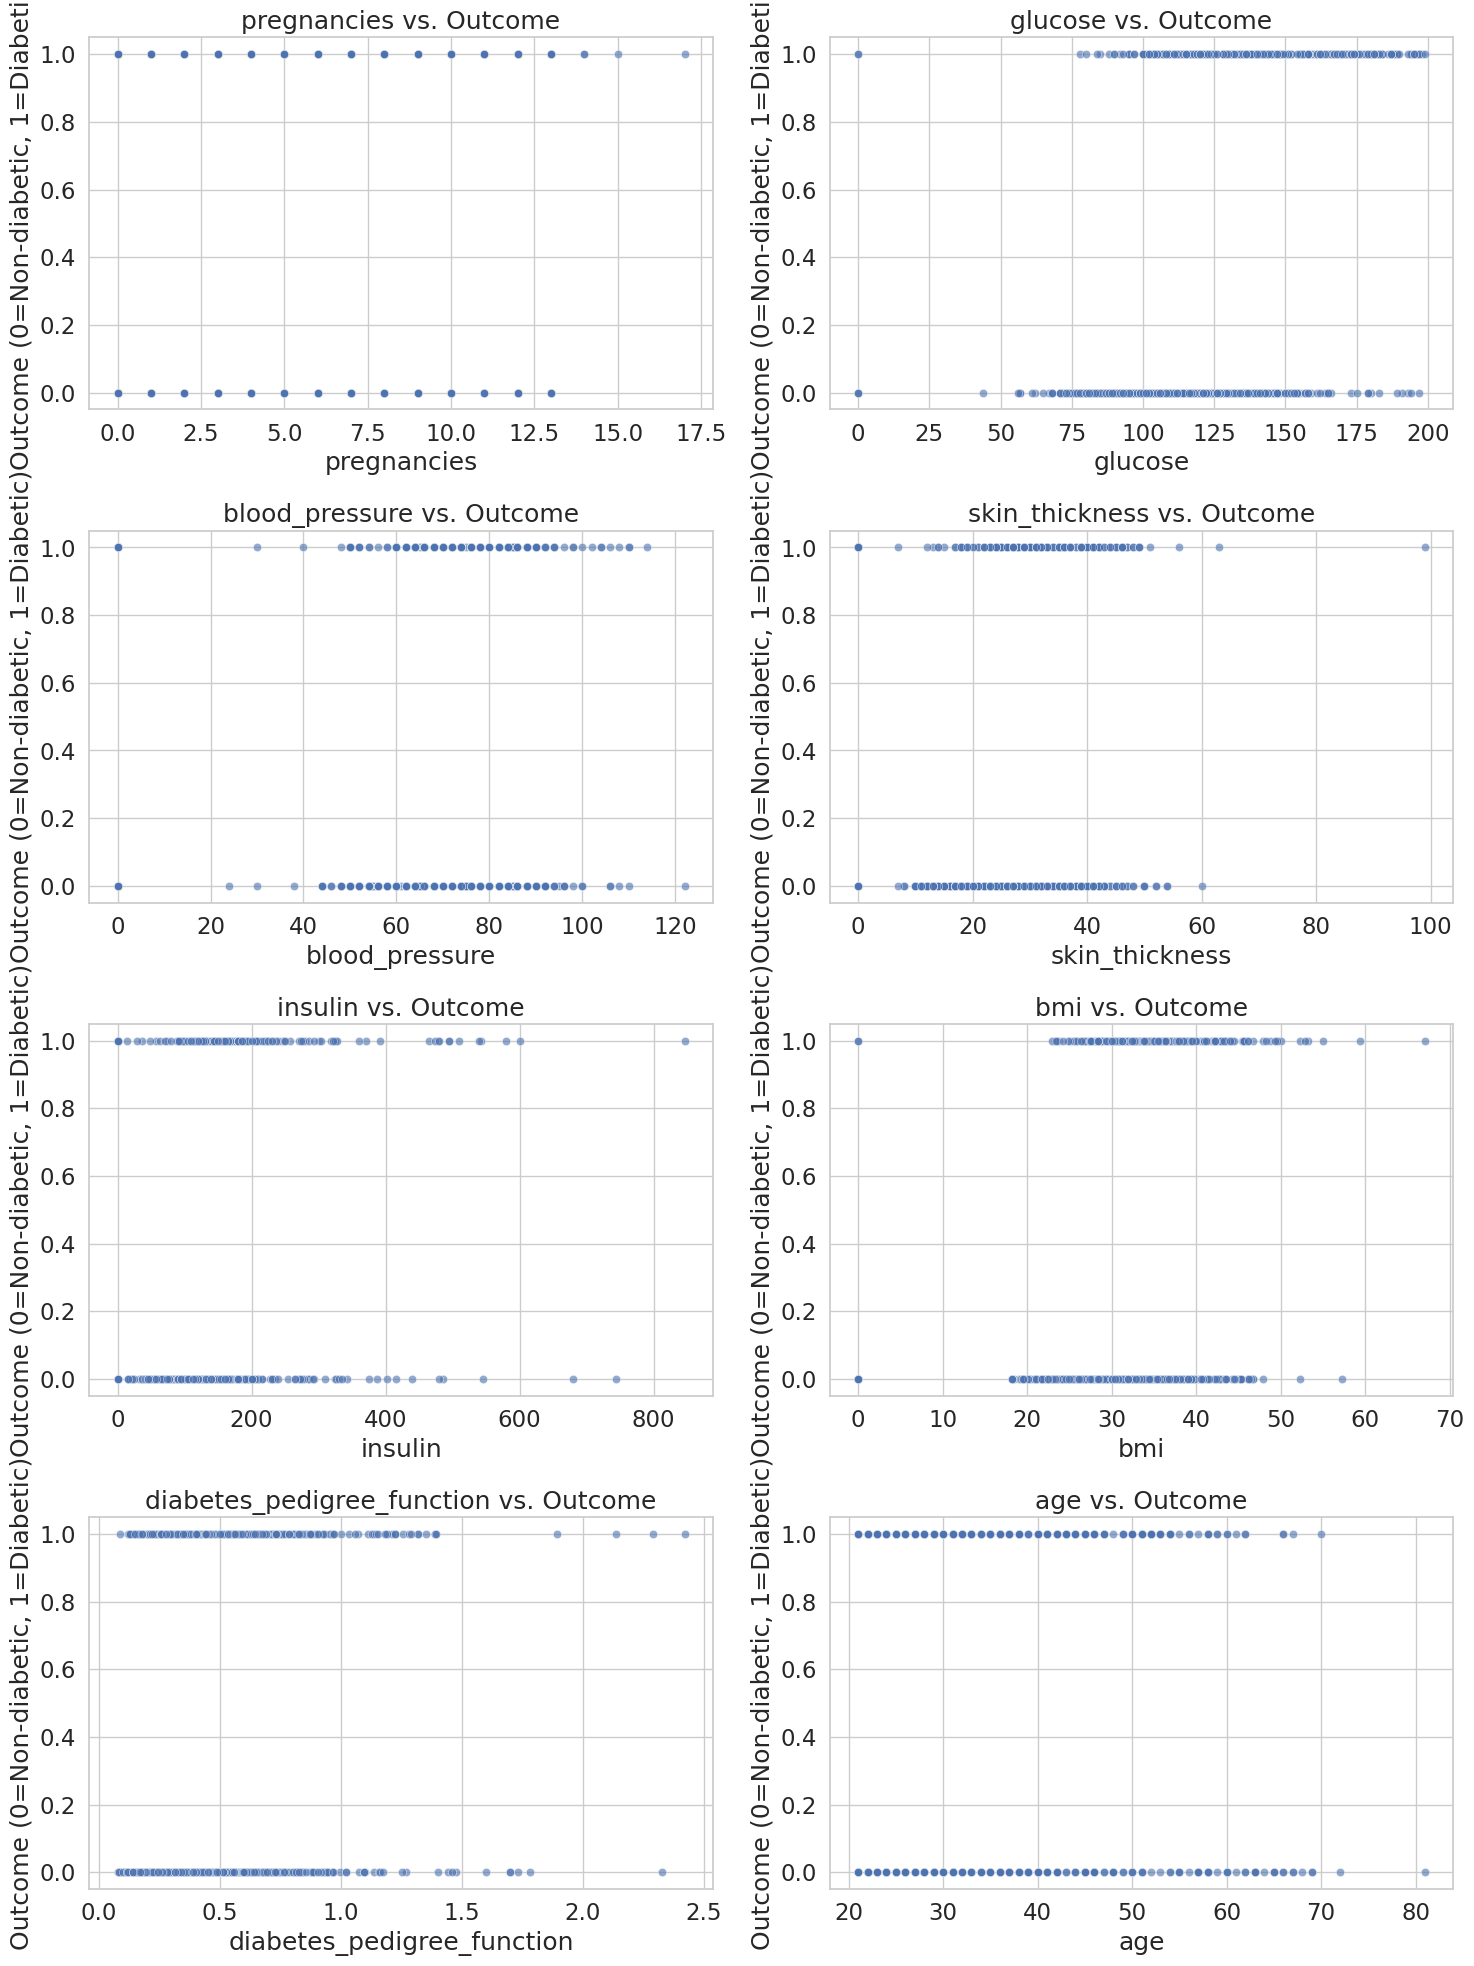

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size for better readability
plt.figure(figsize=(15, 20))

# Iterate through each feature and create a scatter plot against the outcome
for i, feature in enumerate(pima_feature_names):
    plt.subplot(4, 2, i + 1) # Arrange plots in 4 rows, 2 columns
    sns.scatterplot(x=pima_df[feature], y=pima_df['outcome'], alpha=0.6)
    plt.title(f'{feature} vs. Outcome')
    plt.xlabel(feature)
    plt.ylabel('Outcome (0=Non-diabetic, 1=Diabetic)')

plt.tight_layout()
plt.show()

In [30]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    pima_data, pima_target, test_size=0.20, random_state=42, stratify=pima_target
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)


In [37]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(X=X_train, y=y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [38]:
print("Coefficients:")
for i, name in enumerate(pima_feature_names):
    print(f'{name:>25}: {linear_regression.coef_[i]:.6f}')

print(f'\nIntercept: {linear_regression.intercept_:.6f}')

Coefficients:
              pregnancies: 0.018731
                  glucose: 0.006219
           blood_pressure: -0.001740
           skin_thickness: 0.000776
                  insulin: -0.000193
                      bmi: 0.013461
diabetes_pedigree_function: 0.131719
                      age: 0.002506

Intercept: -0.931929


In [39]:
predicted = linear_regression.predict(X_test)
expected = y_test

print("First five predicted values:")
display(predicted[:5])

print("\nFirst five expected (actual) values:")
display(expected[:5])

First five predicted values:


array([ 0.58440142,  0.1354053 ,  0.32642123,  0.34721643, -0.36571815])


First five expected (actual) values:


array([0, 0, 0, 1, 0])

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for expected and predicted values
df_results = pd.DataFrame()
df_results['Expected'] = pd.Series(expected)
df_results['Predicted'] = pd.Series(predicted)

print("First 5 rows of the results DataFrame:")
display(df_results.head())

First 5 rows of the results DataFrame:


,Expected,Predicted
0,0,0.5844
1,0,0.1354
2,0,0.3264
3,1,0.3472
4,0,-0.3657


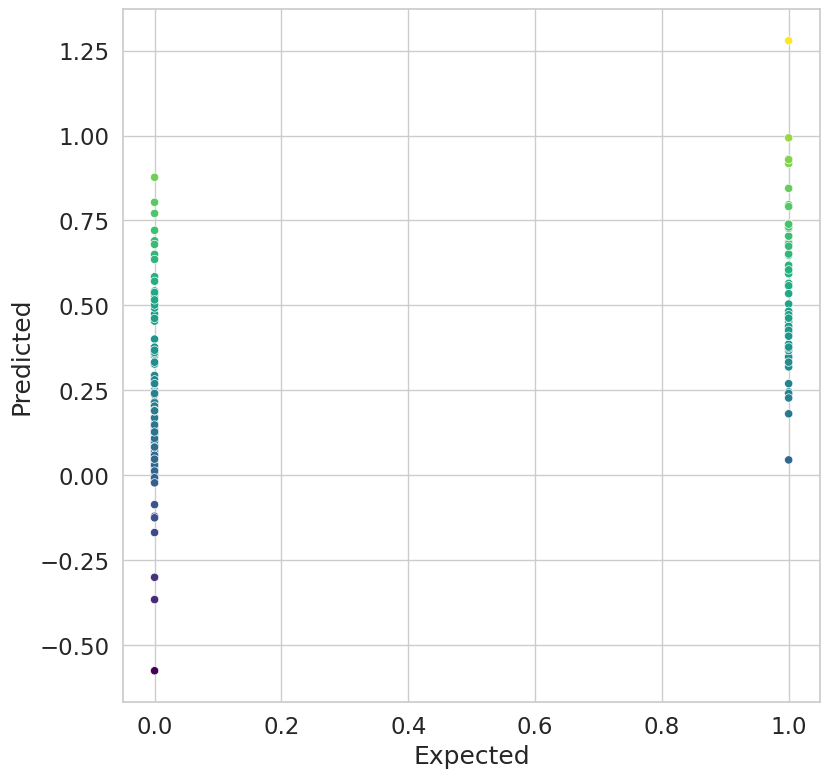

In [41]:
# Plot the data as a scatter plot
figure = plt.figure(figsize=(9, 9))
axes = sns.scatterplot(data=df_results, x='Expected', y='Predicted',
    hue='Predicted', palette='viridis', legend=False)

In [42]:
# Set x- and y-axes limits to use the same scale
start = min(df_results['Expected'].min(), df_results['Predicted'].min())
end = max(df_results['Expected'].max(), df_results['Predicted'].max())

axes.set_xlim(start, end)
axes.set_ylim(start, end)

(-0.5751441369558792, 1.2788851408412547)

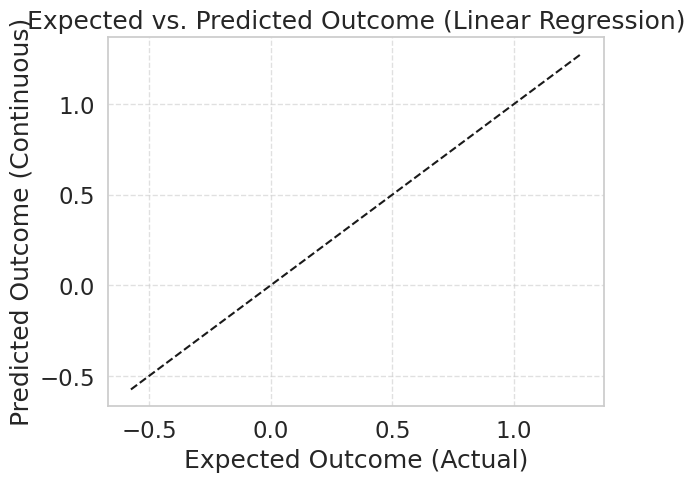

In [43]:
# Plot a line representing perfect predictions
line = plt.plot([start, end], [start, end], 'k--') # 'k--' for black dashed line

plt.title('Expected vs. Predicted Outcome (Linear Regression)')
plt.xlabel('Expected Outcome (Actual)')
plt.ylabel('Predicted Outcome (Continuous)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(expected, predicted)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(expected, predicted)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate R-squared
r_squared = r2_score(expected, predicted)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared: {r_squared:.4f}")

Mean Absolute Error (MAE): 0.3403
Mean Squared Error (MSE): 0.1678
Root Mean Squared Error (RMSE): 0.4096
R-squared: 0.2630


In [46]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge

estimators = {
    'LinearRegression': linear_regression, # Re-using the already trained linear_regression model
    'ElasticNet': ElasticNet(random_state=42), # Added random_state for reproducibility
    'Lasso': Lasso(random_state=42),
    'Ridge': Ridge(random_state=42)
}

In [48]:
from sklearn.model_selection import KFold, cross_val_score

for estimator_name, estimator_object in estimators.items():
    kfold = KFold(n_splits=10, random_state=11, shuffle=True)
    scores = cross_val_score(estimator=estimator_object,
        X=pima_data, y=pima_target, cv=kfold,
        scoring='r2') # Using 'r2' score as specified
    print(f'{estimator_name:>16}: ' +
          f'mean of r2 scores={scores.mean():.3f}')

LinearRegression: mean of r2 scores=0.262
      ElasticNet: mean of r2 scores=0.219
           Lasso: mean of r2 scores=0.195
           Ridge: mean of r2 scores=0.262
